In [21]:
# STEP 1 - Load data
# This cell imports the required libraries, loads the Kaggle CSV, and previews the dataset.
%matplotlib inline

from pathlib import Path
import math

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (10, 6)

# Locate the project root whether the notebook is launched from /github or /github/notebooks.
candidate_roots = [Path.cwd(), Path.cwd().parent]
project_root = next(
    root for root in candidate_roots
    if (root / "data" / "raw" / "online_gaming_behavior_dataset.csv").exists()
)

raw_data_path = project_root / "data" / "raw" / "online_gaming_behavior_dataset.csv"
df = pd.read_csv(raw_data_path)

print("Dataset shape:", df.shape)
print("\nData types:")
print(df.dtypes)
print("\nFirst 5 rows:")
df.head(5)

Dataset shape: (40037, 13)

Data types:
PlayerID                         str
Age                              str
Gender                           str
Location                         str
GameGenre                        str
PlayTimeHours                    str
InGamePurchases                  str
GameDifficulty                   str
SessionsPerWeek                  str
AvgSessionDurationMinutes    float64
PlayerLevel                      str
AchievementsUnlocked             str
EngagementLevel                  str
dtype: object

First 5 rows:


,PlayerID,Age,Gender,Location,GameGenre,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel
0,9000,43,Male,Other,Strategy,16.27111876,0,Medium,6,108.0,79,25,Medium
1,9001,29,Female,USA,Strategy,5.525961381,0,Medium,5,144.0,11,10,Medium
2,9002,22,Female,USA,Sports,8.223755243,0,Easy,16,142.0,35,41,High
3,9003,35,Male,USA,Action,5.265351277,1,Easy,9,85.0,57,47,Medium
4,9004,33,Male,Europe,Action,15.53194452,0,Medium,2,131.0,95,37,Medium


In [22]:
# STEP 2 - Data quality audit
# This cell checks missing values, duplicates, invalid values, and fills them safely.
import numpy as np
import pandas as pd

print("Missing values before cleaning:")
missing_before = df.isnull().sum()
print(missing_before)

print("\nDuplicate rows before cleaning:", df.duplicated().sum())

df = df.drop_duplicates().reset_index(drop=True)

invalid_value_counts = {}

# PlayerID has special handling: repair invalid/missing IDs by continuing after the max valid ID.
if "PlayerID" in df.columns:
    original_player_id = df["PlayerID"].copy()
    df["PlayerID"] = pd.to_numeric(df["PlayerID"], errors="coerce")
    invalid_player_id_mask = df["PlayerID"].isna()
    invalid_value_counts["PlayerID"] = int(invalid_player_id_mask.sum())

    valid_player_ids = df.loc[~invalid_player_id_mask, "PlayerID"]
    if invalid_player_id_mask.any() and not valid_player_ids.empty:
        next_player_id = int(valid_player_ids.max()) + 1
        replacement_ids = range(next_player_id, next_player_id + int(invalid_player_id_mask.sum()))
        df.loc[invalid_player_id_mask, "PlayerID"] = list(replacement_ids)
        print("\nRepaired missing/invalid PlayerID values:")
        print(f"Assigned PlayerID values from {next_player_id} to {next_player_id + int(invalid_player_id_mask.sum()) - 1}")
    elif invalid_player_id_mask.any():
        df = df.loc[~invalid_player_id_mask].reset_index(drop=True)
        print("\nDropped rows with invalid PlayerID because no valid max PlayerID was available.")

    if not df["PlayerID"].isna().any():
        df["PlayerID"] = df["PlayerID"].astype(int)

# Columns that should be numeric. Invalid text values are converted to NaN and then filled with the median.
numeric_columns = [
    "Age",
    "PlayTimeHours",
    "InGamePurchases",
    "SessionsPerWeek",
    "AvgSessionDurationMinutes",
    "PlayerLevel",
    "AchievementsUnlocked",
]

# Columns that should contain only known category labels. Unexpected values are treated like missing values.
allowed_categories = {
    "Gender": ["Male", "Female", "Other"],
    "Location": ["USA", "Europe", "Asia", "Other"],
    "GameGenre": ["Action", "RPG", "Simulation", "Sports", "Strategy"],
    "GameDifficulty": ["Easy", "Medium", "Hard"],
    "EngagementLevel": ["Low", "Medium", "High"],
}

for column in numeric_columns:
    if column in df.columns:
        values_before = df[column].copy()
        df[column] = pd.to_numeric(df[column], errors="coerce")
        invalid_value_counts[column] = int(values_before.notna().sum() - df[column].notna().sum())

for column, valid_values in allowed_categories.items():
    if column in df.columns:
        df[column] = df[column].astype("string").str.strip()
        invalid_mask = df[column].notna() & ~df[column].isin(valid_values)
        invalid_value_counts[column] = int(invalid_mask.sum())
        df.loc[invalid_mask, column] = pd.NA

print("\nInvalid values converted to missing:")
invalid_values_found = False
for column, count in invalid_value_counts.items():
    if count > 0:
        invalid_values_found = True
        print(f"{column}: {count}")
if not invalid_values_found:
    print("No invalid values were found.")

numeric_missing_columns = [column for column in numeric_columns if column in df.columns and df[column].isnull().sum() > 0]
categorical_missing_columns = [column for column in allowed_categories if column in df.columns and df[column].isnull().sum() > 0]

if numeric_missing_columns:
    print("\nNumeric columns filled with median:")
    for column in numeric_missing_columns:
        median_value = df[column].median()
        df[column] = df[column].fillna(median_value)
        print(f"{column}: {median_value}")
else:
    print("\nNo numeric columns had missing values to fill.")

if categorical_missing_columns:
    print("\nCategorical columns filled with mode:")
    for column in categorical_missing_columns:
        mode_values = df[column].mode(dropna=True)
        mode_value = mode_values.iloc[0] if not mode_values.empty else "Unknown"
        df[column] = df[column].fillna(mode_value)
        print(f"{column}: {mode_value}")
else:
    print("\nNo categorical columns had missing values to fill.")

post_fill_duplicates = df.duplicated().sum()
if post_fill_duplicates > 0:
    df = df.drop_duplicates().reset_index(drop=True)

print("\nDuplicate rows after cleaning:", df.duplicated().sum())
print("\nMissing values after cleaning:")
missing_after = df.isnull().sum()
print(missing_after)
print(f"\nClean summary: {missing_after.sum()} total null values remain.")
print(f"Cleaned dataset shape after duplicate removal: {df.shape}")
print("\nEngagementLevel values after cleaning:")
print(df["EngagementLevel"].value_counts())
print("\nLast 5 PlayerID values after cleaning:")
print(df["PlayerID"].tail(5).to_list())

Missing values before cleaning:
PlayerID                     1
Age                          1
Gender                       1
Location                     0
GameGenre                    1
PlayTimeHours                1
InGamePurchases              1
GameDifficulty               2
SessionsPerWeek              1
AvgSessionDurationMinutes    2
PlayerLevel                  1
AchievementsUnlocked         1
EngagementLevel              1
dtype: int64

Duplicate rows before cleaning: 1

Repaired missing/invalid PlayerID values:
Assigned PlayerID values from 49034 to 49035

Invalid values converted to missing:
PlayerID: 2
Age: 1
PlayTimeHours: 1
InGamePurchases: 1
SessionsPerWeek: 1
PlayerLevel: 1
AchievementsUnlocked: 1
Gender: 1
Location: 2
GameGenre: 1
EngagementLevel: 1

Numeric columns filled with median:
Age: 32.0
PlayTimeHours: 12.008002155
InGamePurchases: 0.0
SessionsPerWeek: 9.0
AvgSessionDurationMinutes: 95.0
PlayerLevel: 49.0
AchievementsUnlocked: 25.0

Categorical columns filled wi

EngagementLevel distribution:
EngagementLevel
Medium    0.483939
High      0.258181
Low       0.257881
Name: proportion, dtype: Float64


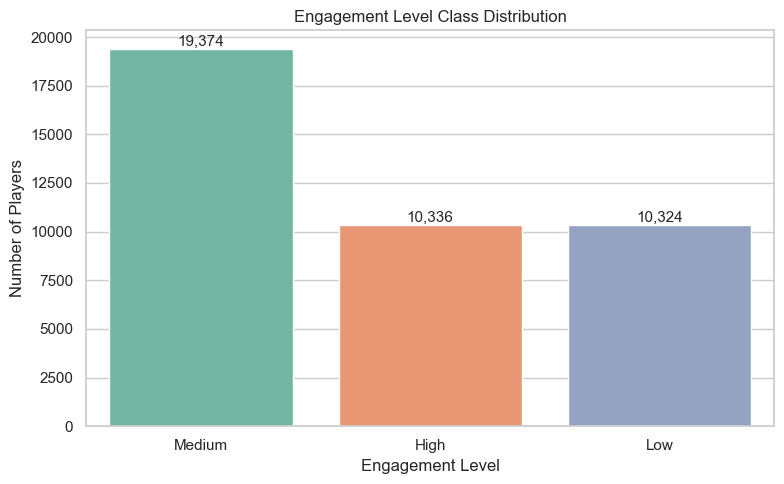

Balance comment: The dataset appears imbalanced because at least one class is much more common than another.


In [18]:
# STEP 3 - Target distribution
# This cell checks how common each EngagementLevel class is and visualizes the class balance.
target_counts = df["EngagementLevel"].value_counts()
target_percentages = df["EngagementLevel"].value_counts(normalize=True)

print("EngagementLevel distribution:")
print(target_percentages)

plt.figure(figsize=(8, 5))
ax = sns.barplot(x=target_counts.index, y=target_counts.values, hue=target_counts.index, legend=False)

for index, count in enumerate(target_counts.values):
    ax.text(index, count, f"{count:,}", ha="center", va="bottom", fontsize=11)

plt.title("Engagement Level Class Distribution")
plt.xlabel("Engagement Level")
plt.ylabel("Number of Players")
plt.tight_layout()
plt.show()

max_share = target_percentages.max()
min_share = target_percentages.min()

if max_share - min_share <= 0.10:
    balance_comment = "The dataset appears reasonably balanced because the class percentages are close to each other."
else:
    balance_comment = "The dataset appears imbalanced because at least one class is much more common than another."

print("Balance comment:", balance_comment)

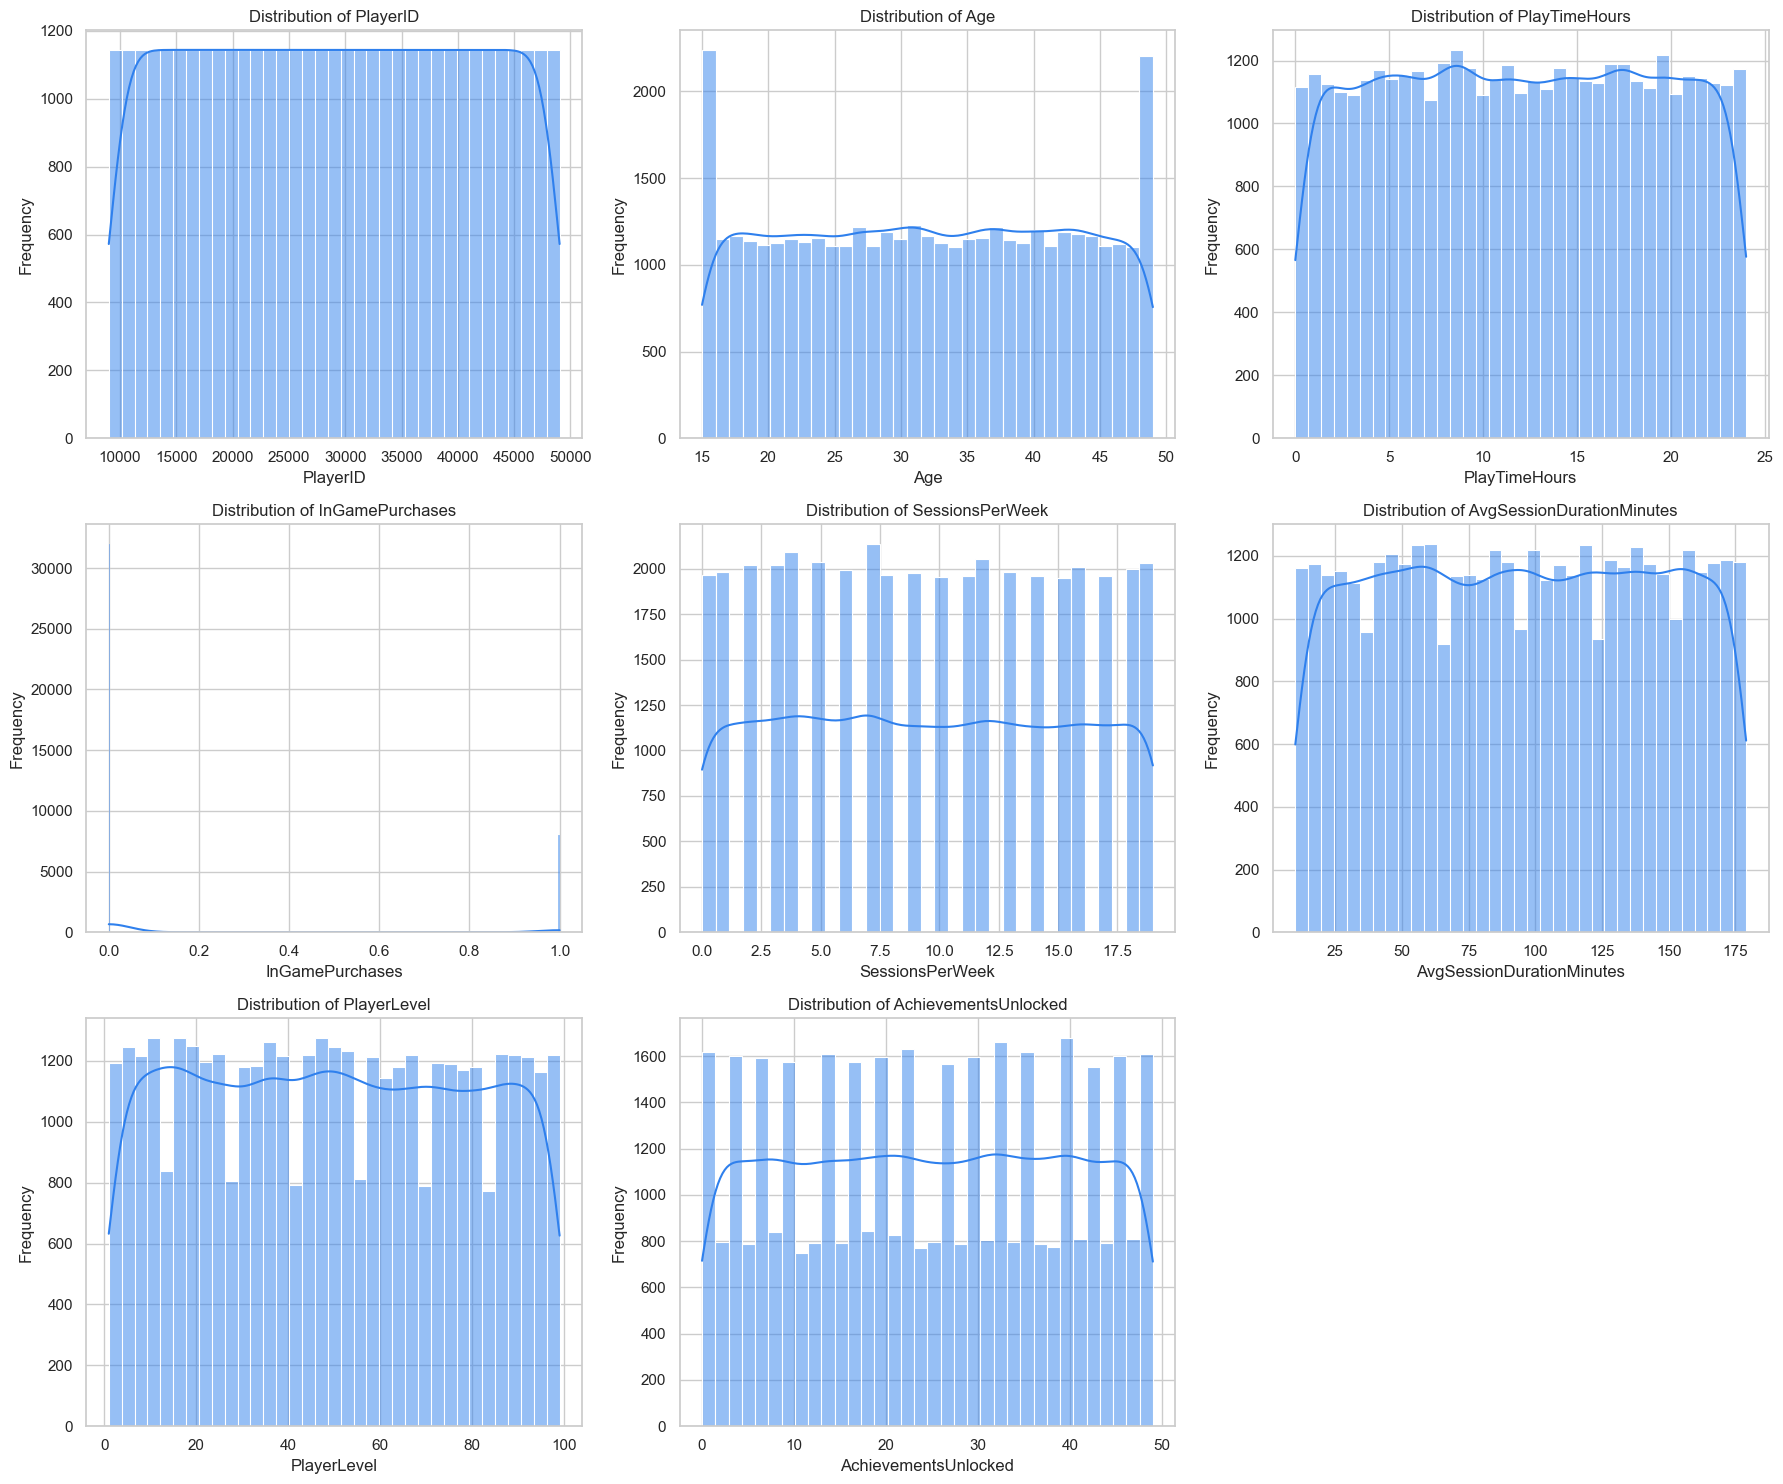

In [19]:
# STEP 4 - Numeric feature distributions
# This cell plots histograms with KDE curves for every numeric feature.
numeric_columns = df.select_dtypes(include=[np.number]).columns

columns_per_row = 3
rows = math.ceil(len(numeric_columns) / columns_per_row)
fig, axes = plt.subplots(rows, columns_per_row, figsize=(18, 5 * rows))
axes = np.array(axes).reshape(-1)

for index, column in enumerate(numeric_columns):
    sns.histplot(data=df, x=column, kde=True, ax=axes[index], color="#2F80ED")
    axes[index].set_title(f"Distribution of {column}")
    axes[index].set_xlabel(column)
    axes[index].set_ylabel("Frequency")

for empty_index in range(len(numeric_columns), len(axes)):
    axes[empty_index].set_visible(False)

plt.tight_layout()
plt.show()

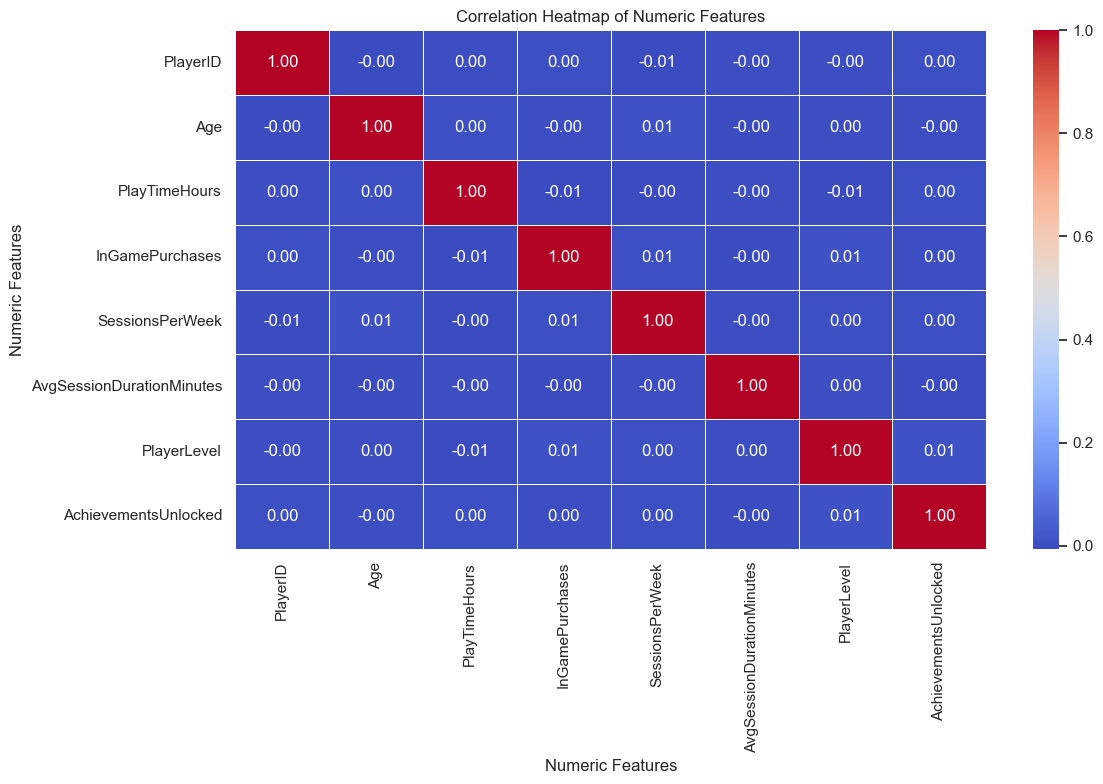

In [20]:
# STEP 5 - Correlation heatmap
# This cell computes correlations between numeric features and visualizes their relationships.
numeric_df = df.select_dtypes(include=[np.number])
correlation_matrix = numeric_df.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Numeric Features")
plt.xlabel("Numeric Features")
plt.ylabel("Numeric Features")
plt.tight_layout()
plt.show()

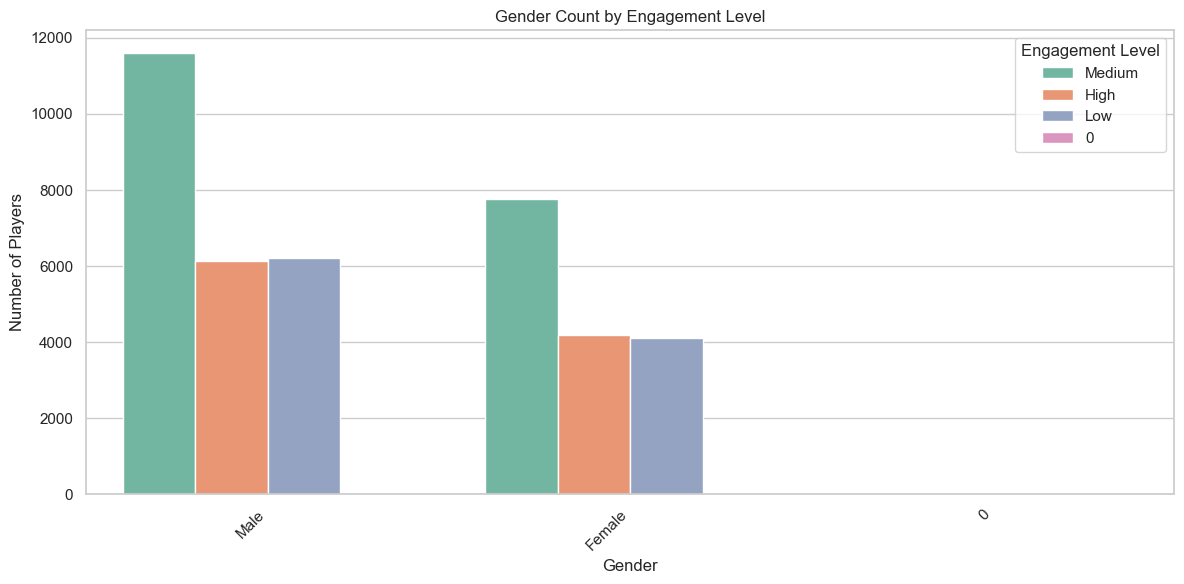

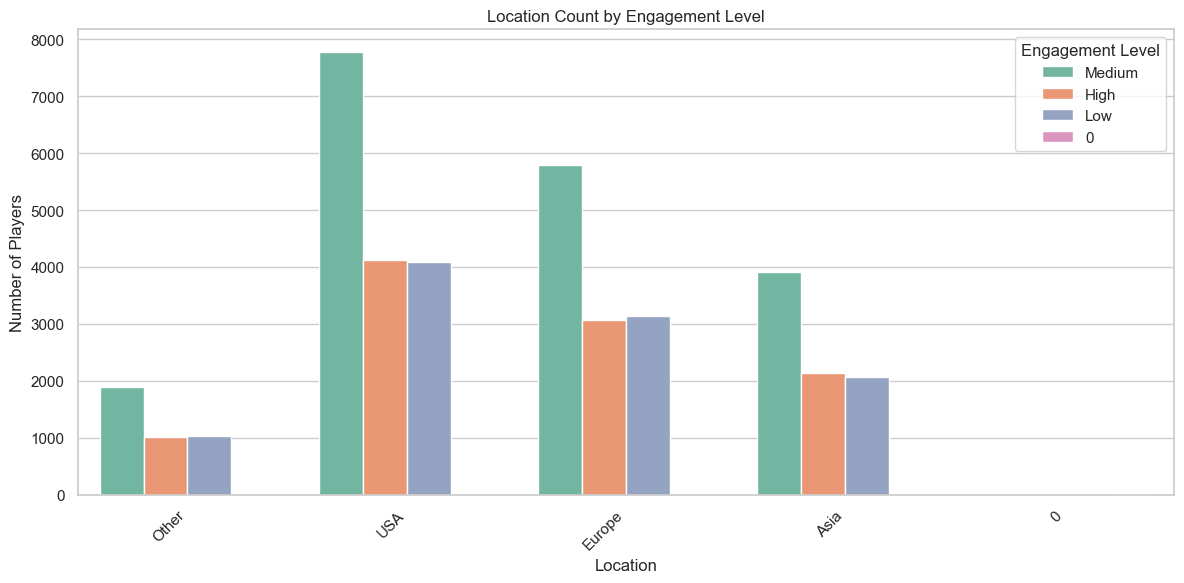

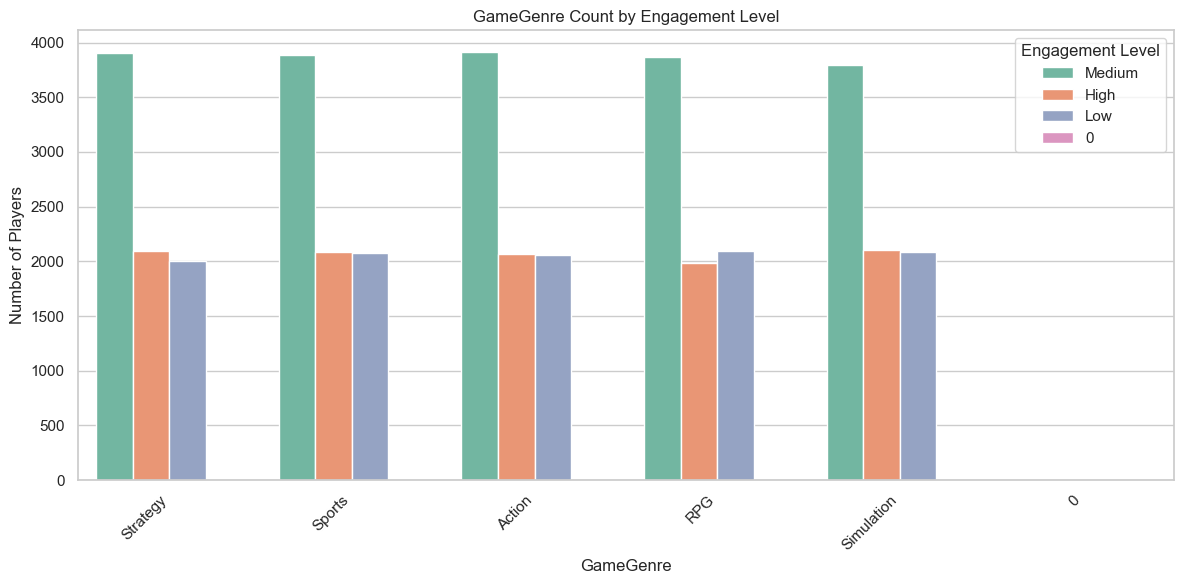

In [10]:
# STEP 6 - Categorical features vs target
# This cell compares Gender, Location, and GameGenre against EngagementLevel using grouped countplots.
categorical_features = ["Gender", "Location", "GameGenre"]

for column in categorical_features:
    plt.figure(figsize=(12, 6))
    ax = sns.countplot(data=df, x=column, hue="EngagementLevel")
    plt.title(f"{column} Count by Engagement Level")
    plt.xlabel(column)
    plt.ylabel("Number of Players")
    plt.xticks(rotation=45, ha="right")
    plt.legend(title="Engagement Level")
    plt.tight_layout()
    plt.show()

In [13]:
# STEP 7 - Save clean dataset
# This cell creates the data folder if needed and saves the cleaned dataset for later ML modeling.
clean_data_path = project_root / "data" / "cleaned_gaming.csv"
clean_data_path.parent.mkdir(parents=True, exist_ok=True)

df.to_csv(clean_data_path, index=False)

print(f"Dataset saved. Shape: {df.shape}")
print(f"Saved to: {clean_data_path}")

Dataset saved. Shape: (40036, 13)
Saved to: C:\Users\Administrator\Desktop\Internship-2025\Internship-Projects\AI\github\data\cleaned_gaming.csv
